# Proyek Analisis Data: Bike-Sharing Dataset
- **Nama:** Andi Zabrina Novrida
- **Email:** andizabrina21@gmail.com

## Menentukan Pertanyaan Bisnis

- Bagaimana pola permintaan bike sharing dari waktu ke waktu?
- Faktor apa yang paling mempengaruhi jumlah penyewaan sepeda?
- Bagaimana perbedaan perilaku antara tipe pengguna?

## Import Semua Packages/Library yang Digunakan

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Data Wrangling

### Gathering Data

In [52]:
day_df = pd.read_csv("https://raw.githubusercontent.com/andizabrina21/Bike_Sharing_Dashboard/main/data/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [53]:
hour_df = pd.read_csv("https://raw.githubusercontent.com/andizabrina21/Bike_Sharing_Dashboard/main/data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

**Menilai Data day_df**

In [54]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Terdapat kesalahan tipe data untuk kolom dteday. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object.

In [55]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


Tidak terdapat missing values

In [56]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


Tidak terdapat duplikasi

In [57]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Tidak terdapat keanehan pada parameter-parameter statistik data day_df

**Menilai Data hour_df**

In [58]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Terdapat kesalahan tipe data untuk kolom dteday. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object.

In [59]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Tidak terdapat missing values

In [60]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


Tidak terdapat duplikasi

In [61]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Tidak terdapat keanehan pada parameter-parameter statistik data hour_df

### Cleaning Data

**Membersihkan Data day_df**

In [62]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

In [63]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Membersihkan Data hour_df**

Menangani kesalahan tipe data

In [64]:
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

In [65]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

## Exploratory Data Analysis (EDA)

### Explore Data hour_df

In [66]:
hour_df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


Berdasarkan rangkuman parameter statistik di atas, diperoleh informasi bahwa rata-rata pengguna yang melakukan penyewaan sepeda ada sebanyak 189 pengguna setiap jam-nya, dimana 35 diantaranya merupakan pengguna biasa dan 153 diantaranya merupakan pengguna terdaftar

#### Perilaku Pengguna

In [67]:
hour_df.groupby(by="yr").agg({
    "casual": "sum",
    "registered": "sum"
})

,casual,registered
yr,,
0,247252,995851
1,372765,1676811


####Statistik Waktu Penggunaan

In [68]:
day_df.groupby(by=["yr"]).agg({
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)

cnt                        
        sum         mean   max  min
yr                                 
0   1243103  3405.761644  6043  431
1   2049576  5599.934426  8714   22

In [69]:
day_df.groupby(by=["mnth"]).agg({
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)

cnt                         
         sum         mean   max   min
mnth                                 
1     134933  2176.338710  4521   431
2     151352  2655.298246  5062  1005
3     228920  3692.258065  8362   605
4     269094  4484.900000  7460   795
5     331686  5349.774194  8294  2633
6     346342  5772.366667  8120  3767
7     344948  5563.677419  8173  3285
8     351194  5664.419355  7865  1115
9     345991  5766.516667  8714  1842
10    322352  5199.225806  8156    22
11    254831  4247.183333  6852  1495
12    211036  3403.806452  6606   441

In [70]:
day_df.groupby(by="weekday").agg({
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)

cnt                         
            sum         mean   max   min
weekday                                 
0        444027  4228.828571  8227   605
1        455503  4338.123810  7525    22
2        469109  4510.663462  7767   683
3        473048  4548.538462  8173   441
4        485395  4667.259615  7804   431
5        487790  4690.288462  8362  1167
6        477807  4550.542857  8714   627

In [71]:
hour_df.groupby(by="hr").agg({
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)

cnt                     
       sum        mean  max min
hr                             
0    39130   53.898072  283   2
1    24164   33.375691  168   1
2    16352   22.869930  132   1
3     8174   11.727403   79   1
4     4428    6.352941   28   1
5    14261   19.889819   66   1
6    55132   76.044138  213   1
7   154171  212.064649  596   1
8   261001  359.011004  839   5
9   159438  219.309491  426  14
10  126257  173.668501  539   8
11  151320  208.143054  663  10
12  184414  253.315934  776   3
13  184919  253.661180  760  11
14  175652  240.949246  750  12
15  183149  251.233196  750   7
16  227748  311.983562  783  11
17  336860  461.452055  976  15
18  309772  425.510989  977  23
19  226789  311.523352  743  11
20  164550  226.030220  567  11
21  125445  172.314560  584   6
22   95612  131.335165  502   9
23   63941   87.831044  256   2

#### Statistika Penggunaan Pola Harian

In [72]:
hour_df.groupby(by=["weekday"]).agg({
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)

cnt                     
            sum        mean  max min
weekday                             
0        444027  177.468825  776   1
1        455503  183.744655  968   1
2        469109  191.238891  970   1
3        473048  191.130505  977   1
4        485395  196.436665  976   1
5        487790  196.135907  957   1
6        477807  190.209793  783   1

In [73]:
hour_df.groupby(by=["workingday"]).agg({
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)#.reset_index()

cnt                     
                sum        mean  max min
workingday                              
0           1000269  181.405332  783   1
1           2292410  193.207754  977   1

#### Statistik Penggunaan terhadap Cuaca

In [74]:
hour_df.groupby(by=["season"]).agg({
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)

cnt                     
            sum        mean  max min
season                              
1        471348  111.114569  801   1
2        918589  208.344069  957   1
3       1061129  236.016237  977   1
4        841613  198.868856  967   1

In [75]:
hour_df.groupby(by=["weathersit"]).agg({
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)

cnt                     
                sum        mean  max min
weathersit                              
1           2338173  204.869272  977   1
2            795952  175.165493  957   1
3            158331  111.579281  891   1
4               223   74.333333  164  23

In [76]:
hour_df.groupby(by="dteday").agg({
    "temp":"mean",
    "windspeed":"mean",
    "hum":"mean",
    "cnt":["sum","mean","max","min"]
})#.sort_values(by=("cnt", "sum"), ascending=False)

temp windspeed       hum   cnt                     
                mean      mean      mean   sum        mean  max min
dteday                                                             
2011-01-01  0.344167  0.160446  0.805833   985   41.041667  110   1
2011-01-02  0.363478  0.248539  0.696087   801   34.826087   93   1
2011-01-03  0.196364  0.248309  0.437273  1349   61.318182  157   1
2011-01-04  0.200000  0.160296  0.590435  1562   67.913043  212   1
2011-01-05  0.226957  0.186900  0.436957  1600   69.565217  195   2
...              ...       ...       ...   ...         ...  ...  ..
2012-12-27  0.254167  0.350133  0.652917  2114   88.083333  257   1
2012-12-28  0.253333  0.155471  0.590000  3095  128.958333  271   2
2012-12-29  0.253333  0.124383  0.752917  1341   55.875000  147   3
2012-12-30  0.255833  0.350754  0.483333  1796   74.833333  169   2
2012-12-31  0.215833  0.154846  0.577500  2729  113.708333  315   1

[731 rows x 7 columns]

#### Hubungan

In [77]:
hour_df.corr()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,0.999995,0.404046,0.866014,0.489164,-0.004775,0.014723,0.001357,-0.003416,-0.014198,0.136178,0.137615,0.009577,-0.074505,0.158295,0.282046,0.278379
dteday,0.999995,1.000000,0.404452,0.865648,0.489808,-0.006161,0.014737,0.001372,-0.003366,-0.014063,0.136074,0.137543,0.010196,-0.074645,0.157821,0.281450,0.277753
season,0.404046,0.404452,1.000000,-0.010742,0.830386,-0.006117,-0.009585,-0.002335,0.013743,-0.014524,0.312025,0.319380,0.150625,-0.149773,0.120206,0.174226,0.178056
yr,0.866014,0.865648,-0.010742,1.000000,-0.010473,-0.003867,0.006692,-0.004485,-0.002196,-0.019157,0.040913,0.039222,-0.083546,-0.008740,0.142779,0.253684,0.250495
mnth,0.489164,0.489808,0.830386,-0.010473,1.000000,-0.005772,0.018430,0.010400,-0.003477,0.005400,0.201691,0.208096,0.164411,-0.135386,0.068457,0.122273,0.120638
hr,-0.004775,-0.006161,-0.006117,-0.003867,-0.005772,1.000000,0.000479,-0.003498,0.002285,-0.020203,0.137603,0.133750,-0.276498,0.137252,0.301202,0.374141,0.394071
holiday,0.014723,0.014737,-0.009585,0.006692,0.018430,0.000479,1.000000,-0.102088,-0.252471,-0.017036,-0.027340,-0.030973,-0.010588,0.003988,0.031564,-0.047345,-0.030927
weekday,0.001357,0.001372,-0.002335,-0.004485,0.010400,-0.003498,-0.102088,1.000000,0.035955,0.003311,-0.001795,-0.008821,-0.037158,0.011502,0.032721,0.021578,0.026900
workingday,-0.003416,-0.003366,0.013743,-0.002196,-0.003477,0.002285,-0.252471,0.035955,1.000000,0.044672,0.055390,0.054667,0.015688,-0.011830,-0.300942,0.134326,0.030284
weathersit,-0.014198,-0.014063,-0.014524,-0.019157,0.005400,-0.020203,-0.017036,0.003311,0.044672,1.000000,-0.102640,-0.105563,0.418130,0.026226,-0.152628,-0.120966,-0.142426


## Visualization & Explanatory Analysis

#### KPI

In [78]:
daily_sharing_df = hour_df.resample(rule='D', on='dteday').agg({
    "cnt": "sum",
    "casual": "sum",
    "registered": "sum"
})
daily_sharing_df = daily_sharing_df.reset_index()
daily_sharing_df.rename(columns={
    "cnt": "total users"
}, inplace=True)
daily_sharing_df.head()

,dteday,total users,casual,registered
0,2011-01-01,985,331,654
1,2011-01-02,801,131,670
2,2011-01-03,1349,120,1229
3,2011-01-04,1562,108,1454
4,2011-01-05,1600,82,1518


In [79]:
peak_hour = hour_df.groupby("hr")["cnt"].sum().idxmax()

print(f"Peak Hour: {peak_hour}:00")

Peak Hour: 17:00


### Pertanyaan 1: Bagaimana pola permintaan bike sharing dari waktu ke waktu?



/tmp/ipykernel_3159/3603061475.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


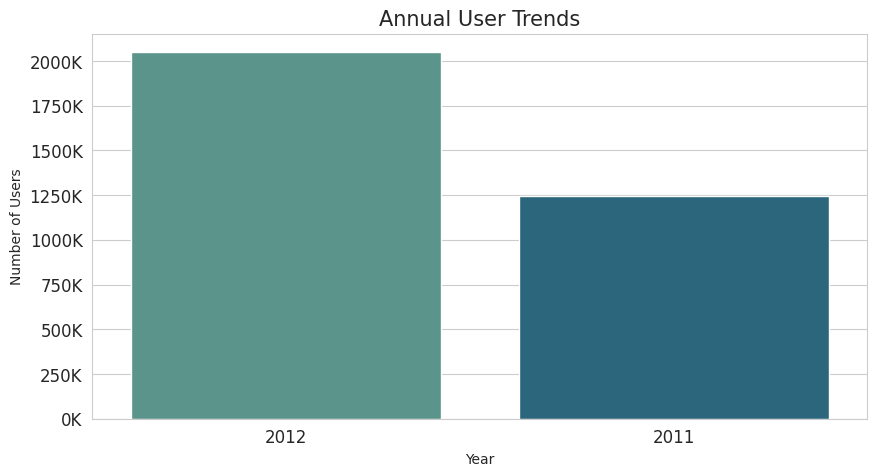

In [80]:
#PER YEAR
byyear_df = hour_df.groupby(by="yr").cnt.sum().reset_index()
byyear_df.rename(columns={
    "cnt": "count"
}, inplace=True)

byyear_df['yr'] = pd.Categorical(byyear_df['yr'].map({0: '2011', 1: '2012'}), ordered=True)

plt.figure(figsize=(10, 5))
colors = 'crest'
sns.barplot(
    y="count",
    x="yr",
    data=byyear_df,
    order = byyear_df.sort_values(by="count", ascending=False).yr,
    palette=colors
)
plt.title("Annual User Trends", loc="center", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Number of Users")
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tick_params(labelsize=12)
plt.show()

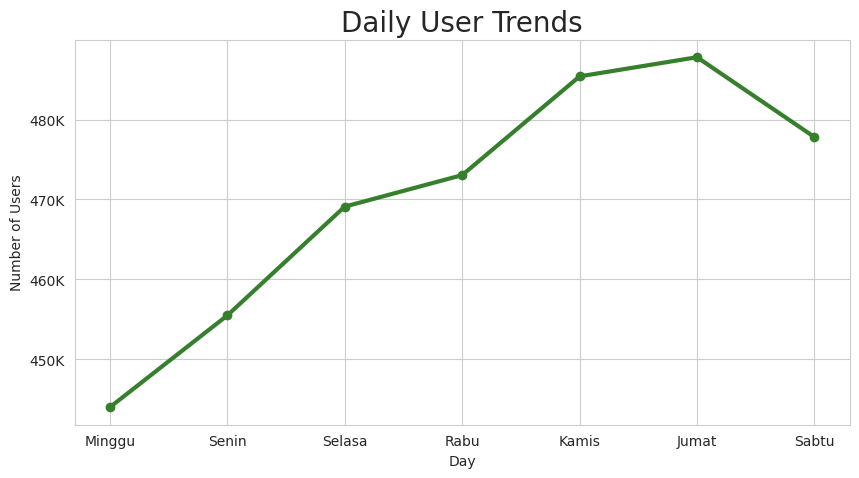

In [81]:
#PER DAY
byday_df = hour_df.groupby(by="weekday").cnt.sum().reset_index()
byday_df.rename(columns={
    "cnt": "count",
}, inplace=True)

byday_df['weekday'] = pd.Categorical(byday_df['weekday'].map({0: 'Minggu',1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'}), ordered=True)

plt.figure(figsize=(10, 5))
plt.plot(
    byday_df["weekday"],
    byday_df["count"],
    marker='o',
    linewidth=3,
    color="#36802D",
)
plt.title("Daily User Trends", loc="center", fontsize=20)
plt.xlabel("Day")
plt.ylabel("Number of Users")
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

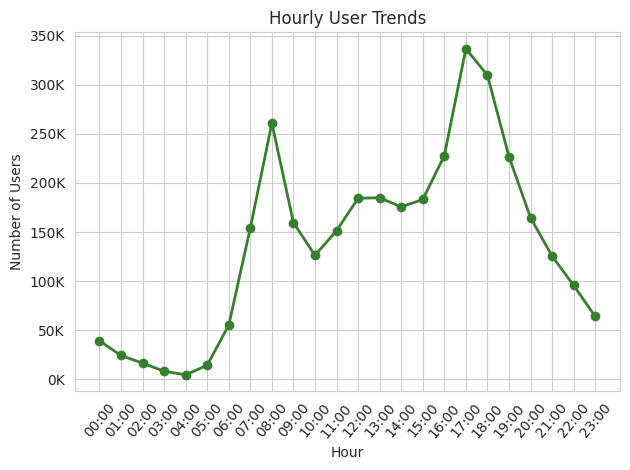

In [82]:
#PER HOUR
byhours_df = hour_df.groupby(by="hr").cnt.sum().reset_index()
byhours_df.rename(columns={
    "cnt": "count"
}, inplace=True)

plt.plot(
    byhours_df['hr'],#.unique(),
    byhours_df["count"],
    marker='o',
    markersize=6,
    linewidth=2,
    color="#36802D",
)
plt.title("Hourly User Trends")
plt.xlabel("Hour")
plt.ylabel("Number of Users")
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.xticks(range(24), labels=[f"{i:02d}:00" for i in range(24)], rotation=50)#, ha='right')
plt.tight_layout()
plt.show()

### Pertanyaan 2 :  Faktor apa yang paling mempengaruhi jumlah penyewaan sepeda?

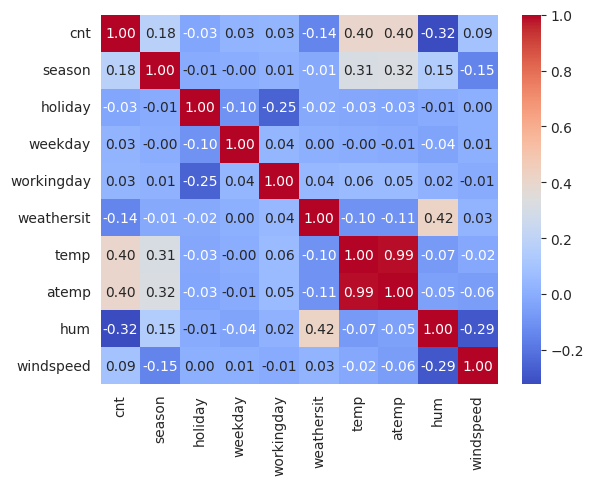

In [83]:
cols = ["cnt", "season", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]
subset = hour_df[cols].corr()

sns.heatmap(subset, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

/tmp/ipykernel_3159/2083913482.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


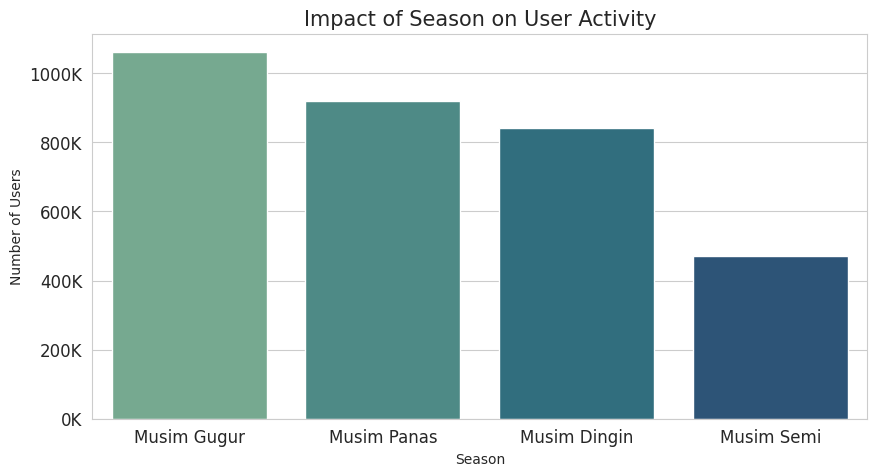

In [84]:
#PENGARUH MUSIM
byseason_df = hour_df.groupby(by="season").cnt.sum().reset_index()
byseason_df.rename(columns={
    "cnt": "count"
}, inplace=True)

byseason_df['season'] = pd.Categorical(byseason_df['season'].map({1: 'Musim Semi',2: 'Musim Panas', 3: 'Musim Gugur', 4: 'Musim Dingin'}), ordered=True)

plt.figure(figsize=(10, 5))
color = 'crest'
sns.barplot(
    y="count",
    x="season",
    data = byseason_df,
    order = byseason_df.sort_values(by="count", ascending=False).season,
    palette=color
)
plt.title("Impact of Season on User Activity", loc="center", fontsize=15)
plt.xlabel("Season")
plt.ylabel("Number of Users")
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tick_params(labelsize=12)
plt.show()

/tmp/ipykernel_3159/482681946.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


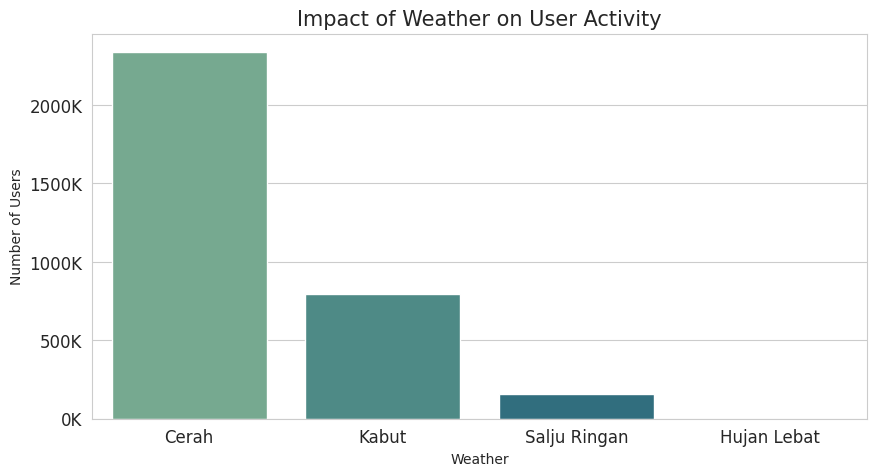

In [85]:
#PENGARUH CUACA
byweather_df = hour_df.groupby(by="weathersit").cnt.sum().reset_index()
byweather_df.rename(columns={
    "cnt": "count"
}, inplace=True)

byweather_df['weathersit'] = pd.Categorical(byweather_df['weathersit'].map({1: 'Cerah',2: 'Kabut', 3: 'Salju Ringan', 4: 'Hujan Lebat'}), ordered=True)

colors= 'crest'
plt.figure(figsize=(10, 5))

sns.barplot(
    y="count",
    x="weathersit",
    data = byweather_df,
    order = byweather_df.sort_values(by="count", ascending=False).weathersit,
    palette=colors
)
plt.title("Impact of Weather on User Activity", loc="center", fontsize=15)
plt.xlabel("Weather")
plt.ylabel("Number of Users")
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tick_params(labelsize=12)
plt.show()

### Pertanyaan 3: Bagaimana perbedaan perilaku antara tipe pengguna?

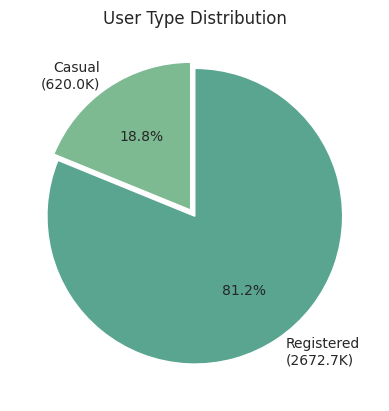

In [86]:
# aktifkan style seaborn
sns.set_style("whitegrid")


# total data
casual_total = daily_sharing_df["casual"].sum()
registered_total = daily_sharing_df["registered"].sum()

labels = [
    f"Casual\n({casual_total/1000:.1f}K)",
    f"Registered\n({registered_total/1000:.1f}K)"
]
sizes = [casual_total, registered_total]

# ambil warna dari seaborn
colors = sns.color_palette("crest")

# plot pie chart
plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0)
)

plt.title('User Type Distribution')
plt.show()

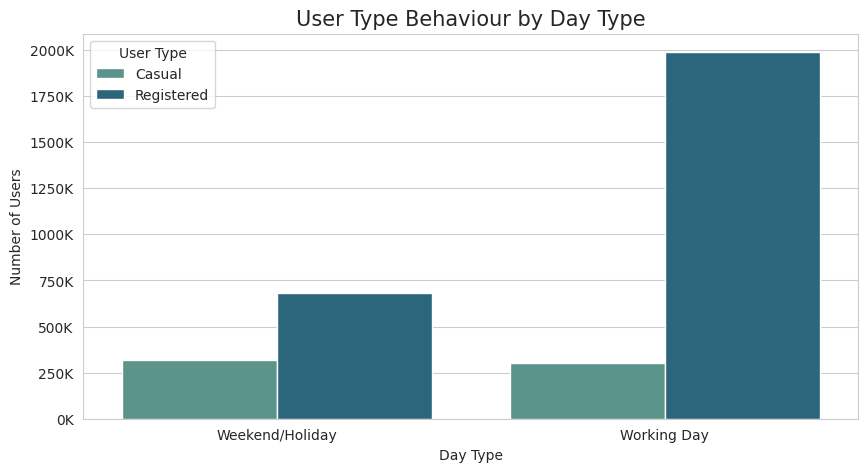

In [87]:
byday_df = hour_df.groupby("workingday")[["casual", "registered"]].sum().reset_index()

# ubah label
byday_df['workingday'] = byday_df['workingday'].map({
    0: 'Weekend/Holiday',
    1: 'Working Day'
})

byday_df.rename(columns={
    "casual": "Casual",
    "registered": "Registered"
}, inplace=True)

# ubah ke format panjang (biar bisa barplot)
byday_df = byday_df.melt(id_vars="workingday",
                        var_name="user_type",
                        value_name="count")

plt.figure(figsize=(10, 5))

sns.barplot(
    y="count",
    x="workingday",
    hue="user_type",
    data=byday_df,
    palette= 'crest'
)

plt.title("User Type Behaviour by Day Type", fontsize=15)
plt.ylabel("Number of Users")
plt.xlabel("Day Type")
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.legend(title="User Type")
plt.show()

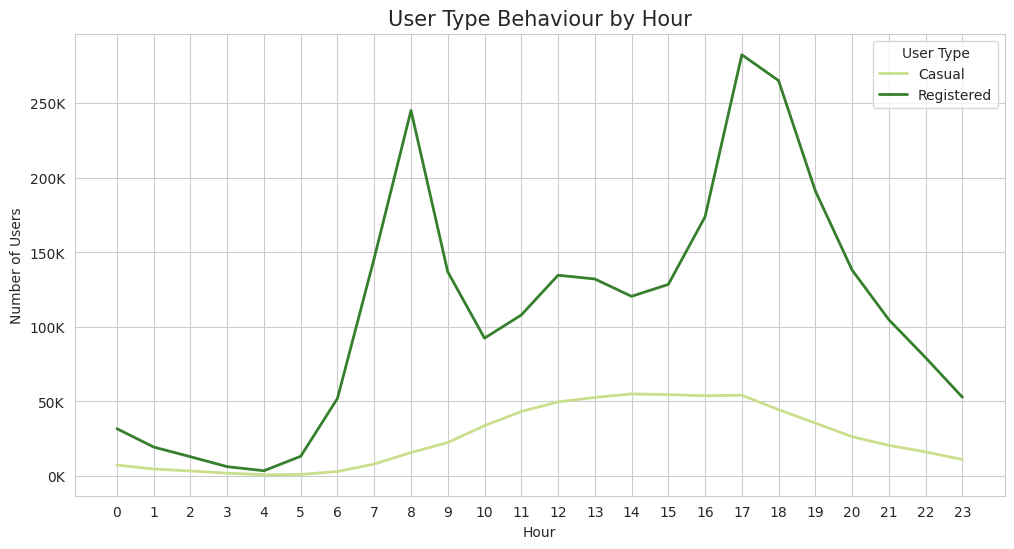

In [88]:
byhour_df = hour_df.groupby("hr")[["casual", "registered"]].sum().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=byhour_df,
    x="hr",
    y="casual",
    color="#C9DF8B",
    label="Casual",
    linewidth=2
)

sns.lineplot(
    data=byhour_df,
    x="hr",
    y="registered",
    color="#36802D",
    label="Registered",
    linewidth=2
)

plt.title("User Type Behaviour by Hour", fontsize=15)
plt.xlabel("Hour")
plt.ylabel("Number of Users")
plt.xticks(range(0,24))
# format ke ribuan
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.legend(title="User Type")
plt.show()

## Conclusion

- Menjelang akhir pekan yaitu pada hari Kamis, Jumat dan Sabtu pada jam 17.00-18.00 terjadi kenaikan jumlah pengguna bike-sharing dibandingkan hari-hari dan jam-jam yang lainnya.
- Terjadi kenaikan jumlah pengguna bike-sharing yang cukup signifikan dari tahun 2011 ke tahun 2012 yaitu sekitar 1 juta pengguna
- Mayoritas pengguna bike-sharing melakukan penyewaan sepeda pada musim gugur, ketika cuaca sedang cerah, sedikit awan ataupun berawan sebagian.
- Mayoritas pengguna bike-sharing melakukan penyewaan ketika hari kerja dan bukan hari libur

In [89]:
day_df.to_csv("data_day.csv", index=False)

In [91]:
hour_df.to_csv("data_hour.csv", index=False)

In [ ]:
#!pip freeze > requirements.txt